## Computer Engineering 
## Machine Learning — Regression (Neural Network)

Name: **Robb Ryan P. Calvez**  Date: **06/02/2026**  
Year & Section: **BSCpE 3-A**  
Course: **Computer Engineering - Embedded Systems**

**MIDTERM EXAM 1**


---

**Import Libraries**

In [1]:
import tensorflow as tf 
import pandas as pd 
import numpy as np 
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f'tensorflow: {tf.__version__}\n', 
      f'pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}')

I0000 00:00:1780400672.659187   11568 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow: 2.21.0
 pandas: 3.0.2
 numpy: 2.4.2
 sklearn: 1.8.0


**Import Datasets**

In [2]:
data1 = pd.read_csv("work/ai-1/Assessments/PrelimExam/Problem1Data.csv")
data2 = pd.read_csv("work/ai-1/Assessments/PrelimExam/Problem2Data.csv")
data3 = pd.read_csv("work/ai-1/Assessments/PrelimExam/Problem3Data.csv")

data1

,Day ID,Weather,Panel Brand,Irradiance (W/m²),Temp (°C),Tilt (°),Age (mo),Dust (g/m²),Output (kWh)
0,D-001,Partly Cloudy,SolarX,720,32,15,6,1.2,28.4
1,D-002,Cloudy,VoltMax,580,29,15,18,3.5,21.8
2,D-003,Sunny,SolarX,810,34,20,3,0.8,32.1
3,D-004,Overcast,GreenRay,430,27,15,36,6.0,14.7
4,D-005,Partly Cloudy,VoltMax,650,31,25,12,2.1,24.9
5,D-006,Sunny,SolarX,760,33,20,8,1.5,30.2
6,D-007,Cloudy,GreenRay,510,28,15,24,4.8,18.3
7,D-008,Sunny,SolarX,890,35,25,2,0.5,34.7
8,D-009,Overcast,GreenRay,380,26,10,48,7.2,11.5
9,D-010,Partly Cloudy,VoltMax,690,31,20,14,2.8,26.0


### Question 1 - Rooftop Solar Inverter Output 

In [3]:
prob1_X = data1.drop(['Output (kWh)'], axis=1)
prob1_y = data1['Output (kWh)']

prob1_X, prob1_y

(   Day ID        Weather Panel Brand  Irradiance (W/m²)  Temp (°C)  Tilt (°)  \
 0   D-001  Partly Cloudy      SolarX                720         32        15   
 1   D-002         Cloudy     VoltMax                580         29        15   
 2   D-003          Sunny      SolarX                810         34        20   
 3   D-004       Overcast    GreenRay                430         27        15   
 4   D-005  Partly Cloudy     VoltMax                650         31        25   
 5   D-006          Sunny      SolarX                760         33        20   
 6   D-007         Cloudy    GreenRay                510         28        15   
 7   D-008          Sunny      SolarX                890         35        25   
 8   D-009       Overcast    GreenRay                380         26        10   
 9   D-010  Partly Cloudy     VoltMax                690         31        20   
 10  D-011         Cloudy     VoltMax                540         30        15   
 11  D-012          Sunny   

**Split dataset into Train/Test sets**

In [4]:
prob1_X_train, prob1_X_test, prob1_y_train, prob1_y_test = train_test_split(prob1_X, prob1_y,
                                                                            shuffle=False,
                                                                            test_size=0.25
                                                                            )
prob1_X_train

,Day ID,Weather,Panel Brand,Irradiance (W/m²),Temp (°C),Tilt (°),Age (mo),Dust (g/m²)
0,D-001,Partly Cloudy,SolarX,720,32,15,6,1.2
1,D-002,Cloudy,VoltMax,580,29,15,18,3.5
2,D-003,Sunny,SolarX,810,34,20,3,0.8
3,D-004,Overcast,GreenRay,430,27,15,36,6.0
4,D-005,Partly Cloudy,VoltMax,650,31,25,12,2.1
5,D-006,Sunny,SolarX,760,33,20,8,1.5
6,D-007,Cloudy,GreenRay,510,28,15,24,4.8
7,D-008,Sunny,SolarX,890,35,25,2,0.5
8,D-009,Overcast,GreenRay,380,26,10,48,7.2
9,D-010,Partly Cloudy,VoltMax,690,31,20,14,2.8


**Encode and Scale dataset**

In [5]:
ct = make_column_transformer(
    (OneHotEncoder(), ['Weather', 'Panel Brand']), #OneHotEncoder() on categorical data 
    (StandardScaler(), ['Irradiance (W/m²)', 'Temp (°C)', 'Tilt (°)', 'Age (mo)', 'Dust (g/m²)']) #StandardScaler() as the z-score scaler
)

ct.fit(prob1_X_train)

prob1_X_train_scaled = ct.transform(prob1_X_train)
prob1_X_test_scaled = ct.transform(prob1_X_test)


In [6]:

prob1_X_train_scaled[0]

array([ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  0.57597128,  0.56171733,
       -0.76088591, -0.97454472, -1.00399945])

**Create Model**

In [ ]:
tf.random.set_seed(42)

prob1_model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(13,)), 
  tf.keras.layers.Dense(16, activation='relu'),
  tf.keras.layers.Dense(8, activation='relu'),
  tf.keras.layers.Dense(1,  activation='linear')
])

prob1_model.compile(loss='mse',
                          optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
                          )

history1 = prob1_model.fit(prob1_X_train_scaled, prob1_y_train, 
                           epochs=200, 
                           verbose=0,
                           batch_size=8
                           ) 

I0000 00:00:1780334561.802823   95748 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1780334564.012517   95930 service.cc:153] XLA service 0x702ac80317d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780334564.012577   95930 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1780334564.040745   95930 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780334564.189436   95930 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1780334564.202530   95930 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1160__.7
I0000 00:00:1780334565.405852

**Evaluate Model**

In [10]:
prob1_y_pred = prob1_model.predict(prob1_X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step


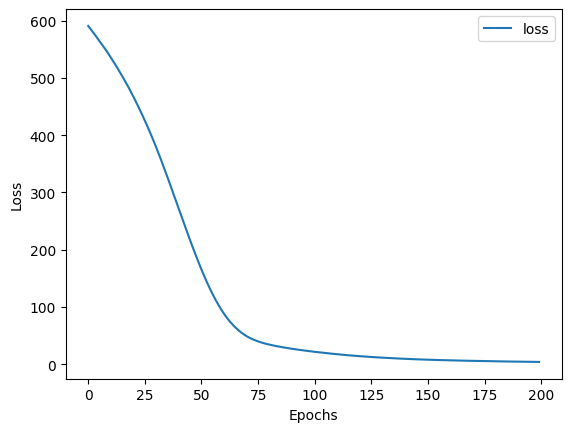

In [8]:
pd.DataFrame(history1.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

In [12]:
mae = mean_absolute_error(prob1_y_test, prob1_y_pred)
rmse = np.sqrt(mean_squared_error(prob1_y_test, prob1_y_pred))
r2 = r2_score(prob1_y_test, prob1_y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 1.4654
RMSE: 1.7915
R²: 0.9431


In [14]:
comparison = pd.DataFrame({
    'Actual': prob1_y_test,
    'Predicted': prob1_y_pred.flatten(),
    'Error': prob1_y_test - prob1_y_pred.flatten()
})
print(comparison)

    Actual  Predicted     Error
30    32.0  31.574574  0.425426
31    20.0  19.034611  0.965389
32    11.0  14.213167 -3.213167
33    29.1  31.593945 -2.493945
34    22.4  21.259996  1.140004
35    30.0  31.099356 -1.099356
36    17.0  14.438525  2.561475
37    33.5  35.789692 -2.289692
38    13.4  13.070896  0.329104
39    25.5  25.636276 -0.136276


### Question 2 - Electric Vehicle Remaining Range

In [23]:
data2

,Trip ID,Mode,Road Type,SoC (%),Temp (°C),AC (kW),Elev (m),Speed (km/h),Range (km)
0,T-001,Eco,Urban,80,28,1.2,50,55,232
1,T-002,Sport,Highway,50,35,2.5,120,70,118
2,T-003,Eco,Urban,95,24,0.8,20,50,305
3,T-004,Sport,Mountain,30,33,2.0,200,80,58
4,T-005,Normal,Mixed,65,30,1.5,80,60,175
5,T-006,Eco,Urban,85,26,1.0,40,55,258
6,T-007,Sport,Mountain,45,34,2.2,150,75,92
7,T-008,Eco,Urban,90,25,0.9,30,50,285
8,T-009,Sport,Mountain,25,36,2.8,220,85,42
9,T-010,Normal,Mixed,70,29,1.4,70,60,198


In [24]:
prob2_X = data2.drop(['Range (km)'], axis=1)
prob2_y = data2['Range (km)']

prob2_X, prob2_y

(   Trip ID    Mode Road Type  SoC (%)  Temp (°C)  AC (kW)  Elev (m)  \
 0    T-001     Eco     Urban       80         28      1.2        50   
 1    T-002   Sport   Highway       50         35      2.5       120   
 2    T-003     Eco     Urban       95         24      0.8        20   
 3    T-004   Sport  Mountain       30         33      2.0       200   
 4    T-005  Normal     Mixed       65         30      1.5        80   
 5    T-006     Eco     Urban       85         26      1.0        40   
 6    T-007   Sport  Mountain       45         34      2.2       150   
 7    T-008     Eco     Urban       90         25      0.9        30   
 8    T-009   Sport  Mountain       25         36      2.8       220   
 9    T-010  Normal     Mixed       70         29      1.4        70   
 10   T-011   Sport   Highway       55         32      1.8       110   
 11   T-012     Eco     Urban       88         27      1.1        45   
 12   T-013   Sport  Mountain       40         33      2.3      

**Split dataset into Train/Test sets**

In [25]:
prob2_X_train, prob2_X_test, prob2_y_train, prob2_y_test = train_test_split(prob2_X, prob2_y,
                                                                            shuffle=False,
                                                                            test_size=0.25
                                                                            )
prob2_X_train

,Trip ID,Mode,Road Type,SoC (%),Temp (°C),AC (kW),Elev (m),Speed (km/h)
0,T-001,Eco,Urban,80,28,1.2,50,55
1,T-002,Sport,Highway,50,35,2.5,120,70
2,T-003,Eco,Urban,95,24,0.8,20,50
3,T-004,Sport,Mountain,30,33,2.0,200,80
4,T-005,Normal,Mixed,65,30,1.5,80,60
5,T-006,Eco,Urban,85,26,1.0,40,55
6,T-007,Sport,Mountain,45,34,2.2,150,75
7,T-008,Eco,Urban,90,25,0.9,30,50
8,T-009,Sport,Mountain,25,36,2.8,220,85
9,T-010,Normal,Mixed,70,29,1.4,70,60


**Encode and Scale dataset**

In [26]:
ct = make_column_transformer(
    (OneHotEncoder(), ['Mode', 'Road Type']), #OneHotEncoder() on categorical data 
    (StandardScaler(), ['SoC (%)', 'Temp (°C)', 'AC (kW)', 'Elev (m)', 'Speed (km/h)']) #StandardScaler() as the z-score scaler
)

ct.fit(prob2_X_train)

prob2_X_train_scaled = ct.transform(prob2_X_train)
prob2_X_test_scaled = ct.transform(prob2_X_test)


In [27]:

prob2_X_train_scaled[0]

array([ 1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  0.90339726, -0.75139069, -0.88030731,
       -0.93819755, -1.01253967])

**Create Model**

In [28]:
tf.random.set_seed(42)

prob2_model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(12,)), 
  tf.keras.layers.Dense(16, activation='relu'),
  tf.keras.layers.Dense(8, activation='relu'),
  tf.keras.layers.Dense(1,  activation='linear')
])

prob2_model.compile(loss='mse',
                          optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
                          )

history2 = prob2_model.fit(prob2_X_train_scaled, prob2_y_train, 
                           epochs=200, 
                           verbose=0,
                           batch_size=8
                           ) 

I0000 00:00:1780338006.167484   95930 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6261__.7
I0000 00:00:1780338007.355402   95929 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6261__.7


**Evaluate Model**

In [29]:
prob2_y_pred = prob2_model.predict(prob2_X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


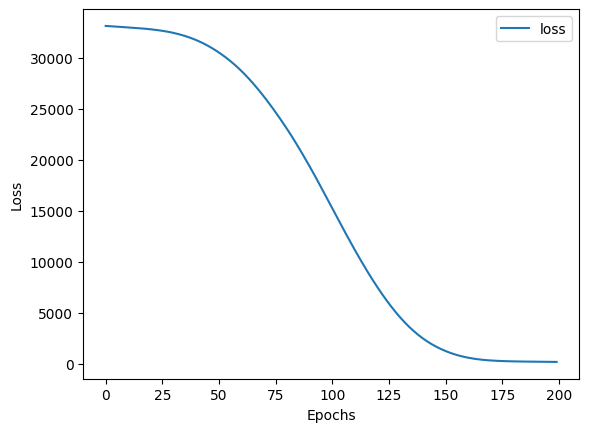

In [30]:
pd.DataFrame(history2.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

In [31]:
mae = mean_absolute_error(prob2_y_test, prob2_y_pred)
rmse = np.sqrt(mean_squared_error(prob2_y_test, prob2_y_pred))
r2 = r2_score(prob2_y_test, prob2_y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 8.4825
RMSE: 11.7757
R²: 0.9816


In [32]:
comparison = pd.DataFrame({
    'Actual': prob2_y_test,
    'Predicted': prob2_y_pred.flatten(),
    'Error': prob2_y_test - prob2_y_pred.flatten()
})
print(comparison)

    Actual   Predicted      Error
30     245  251.713760  -6.713760
31      55   70.822258 -15.822258
32     182  180.410110   1.589890
33     290  297.552826  -7.552826
34     112  107.533760   4.466240
35     160  152.580383   7.419617
36      72   65.931953   6.068047
37     278  275.139893   2.860107
38     212  214.220078  -2.220078
39      45   75.112373 -30.112373


### Question 3 - Data-Center Server Response Latency

In [38]:
data3

,Snap ID,Request Type,Region,CPU (%),Conns,Cache (%),BW (Mbps),Queue,Latency (ms)
0,S-001,Read-Heavy,US-East,45,320,92,850,12,38
1,S-002,Mixed,Asia-Pacific,78,1100,65,320,85,142
2,S-003,Read-Heavy,EU-West,30,180,95,940,5,22
3,S-004,Write-Heavy,Latin-America,88,1500,58,210,130,198
4,S-005,Mixed,US-East,62,720,81,600,40,76
5,S-006,Read-Heavy,EU-West,52,420,88,780,18,48
6,S-007,Write-Heavy,Asia-Pacific,82,1280,60,280,110,175
7,S-008,Read-Heavy,US-East,38,240,93,880,8,28
8,S-009,Write-Heavy,Latin-America,92,1620,55,180,145,215
9,S-010,Mixed,EU-West,68,850,78,540,52,92


In [39]:
prob3_X = data3.drop(['Latency (ms)'], axis=1)
prob3_y = data3['Latency (ms)']

prob3_X, prob3_y

(   Snap ID Request Type         Region  CPU (%)  Conns  Cache (%)  BW (Mbps)  \
 0    S-001   Read-Heavy        US-East       45    320         92        850   
 1    S-002        Mixed   Asia-Pacific       78   1100         65        320   
 2    S-003   Read-Heavy        EU-West       30    180         95        940   
 3    S-004  Write-Heavy  Latin-America       88   1500         58        210   
 4    S-005        Mixed        US-East       62    720         81        600   
 5    S-006   Read-Heavy        EU-West       52    420         88        780   
 6    S-007  Write-Heavy   Asia-Pacific       82   1280         60        280   
 7    S-008   Read-Heavy        US-East       38    240         93        880   
 8    S-009  Write-Heavy  Latin-America       92   1620         55        180   
 9    S-010        Mixed        EU-West       68    850         78        540   
 10   S-011   Read-Heavy        US-East       48    380         89        820   
 11   S-012        Mixed   A

**Split dataset into Train/Test sets**

In [40]:
prob3_X_train, prob3_X_test, prob3_y_train, prob3_y_test = train_test_split(prob3_X, prob3_y,
                                                                            shuffle=False,
                                                                            test_size=0.25
                                                                            )
prob3_X_train

,Snap ID,Request Type,Region,CPU (%),Conns,Cache (%),BW (Mbps),Queue
0,S-001,Read-Heavy,US-East,45,320,92,850,12
1,S-002,Mixed,Asia-Pacific,78,1100,65,320,85
2,S-003,Read-Heavy,EU-West,30,180,95,940,5
3,S-004,Write-Heavy,Latin-America,88,1500,58,210,130
4,S-005,Mixed,US-East,62,720,81,600,40
5,S-006,Read-Heavy,EU-West,52,420,88,780,18
6,S-007,Write-Heavy,Asia-Pacific,82,1280,60,280,110
7,S-008,Read-Heavy,US-East,38,240,93,880,8
8,S-009,Write-Heavy,Latin-America,92,1620,55,180,145
9,S-010,Mixed,EU-West,68,850,78,540,52


**Encode and Scale dataset**

In [41]:
ct = make_column_transformer(
    (OneHotEncoder(), ['Request Type', 'Region']), #OneHotEncoder() on categorical data 
    (StandardScaler(), ['CPU (%)', 'Conns', 'Cache (%)', 'BW (Mbps)', 'Queue']) #StandardScaler() as the z-score scaler
)

ct.fit(prob3_X_train)

prob3_X_train_scaled = ct.transform(prob3_X_train)
prob3_X_test_scaled = ct.transform(prob3_X_test)


In [42]:

prob3_X_train_scaled[0]

array([ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        , -0.91720613, -0.99550607,  1.05896952,
        1.09385136, -0.94776554])

**Create Model**

In [43]:
tf.random.set_seed(42)

prob3_model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(12,)), 
  tf.keras.layers.Dense(16, activation='relu'),
  tf.keras.layers.Dense(8, activation='relu'),
  tf.keras.layers.Dense(1,  activation='linear')
])

prob3_model.compile(loss='mse',
                          optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
                          )

history3 = prob3_model.fit(prob3_X_train_scaled, prob3_y_train, 
                           epochs=200, 
                           verbose=0,
                           batch_size=8
                           ) 

I0000 00:00:1780338380.708315   95929 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11362__.7
I0000 00:00:1780338381.351173   95931 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11362__.7


**Evaluate Model**

In [44]:
prob3_y_pred = prob3_model.predict(prob3_X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step


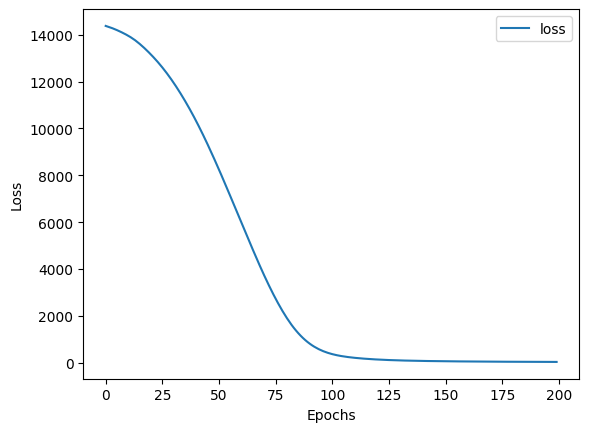

In [48]:
pd.DataFrame(history3.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

In [46]:
mae = mean_absolute_error(prob3_y_test, prob3_y_pred)
rmse = np.sqrt(mean_squared_error(prob3_y_test, prob3_y_pred))
r2 = r2_score(prob3_y_test, prob3_y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 5.0203
RMSE: 6.0414
R²: 0.9927


In [47]:
comparison = pd.DataFrame({
    'Actual': prob3_y_test,
    'Predicted': prob3_y_pred.flatten(),
    'Error': prob3_y_test - prob3_y_pred.flatten()
})
print(comparison)

    Actual   Predicted      Error
30      32   36.763462  -4.763462
31     200  195.767731   4.232269
32     118  116.054604   1.945396
33      24   33.337246  -9.337246
34      62   59.605873   2.394127
35     225  226.516022  -1.516022
36      41   33.684948   7.315052
37      88   83.175720   4.824280
38     180  181.821274  -1.821274
39      55   42.946461  12.053539
